In [2]:
from pathlib import Path
import os

# run this once near top of notebook
if Path.cwd().name == "notebooks":
    os.chdir("..")

print(Path.cwd())

/Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qpitome_qrc.data.loaders import load_market_stress_data

df = load_market_stress_data().copy()

# Contrast features
df["rv_ratio_5_20"] = df["rv_5d"] / df["rv_20d"]
df["rv_ratio_10_20"] = df["rv_10d"] / df["rv_20d"]

# Causal smoothing: uses only past/current values
df["rv_5d_ewm_5"] = df["rv_5d"].ewm(span=5, adjust=False).mean()
df["rv_20d_ewm_5"] = df["rv_20d"].ewm(span=5, adjust=False).mean()

# Derivative-like features
df["rv_5d_slope"] = df["rv_5d"].diff()
df["rv_5d_ewm_slope"] = df["rv_5d_ewm_5"].diff()
df["rv_20d_ewm_slope"] = df["rv_20d_ewm_5"].diff()

# Optional acceleration
df["rv_5d_ewm_accel"] = df["rv_5d_ewm_slope"].diff()

df = df.dropna().reset_index(drop=True)
df.head()

,date,spy_open,spy_high,spy_low,spy_close,spy_adj_close,spy_volume,vix_close,spy_log_return,spy_return,...,future_rv_5d,future_high_vol_label,rv_ratio_5_20,rv_ratio_10_20,rv_5d_ewm_5,rv_20d_ewm_5,rv_5d_slope,rv_5d_ewm_slope,rv_20d_ewm_slope,rv_5d_ewm_accel
0,1993-03-03,45.0000,45.1563,44.9375,45.1250,25.4370,280100,13.13,0.004160,0.004169,...,0.179646,0,0.780195,0.680209,0.104332,0.129334,-0.017820,-0.000184,0.001960,-0.008818
1,1993-03-04,45.1875,45.1875,44.8750,44.8750,25.2961,89500,13.44,-0.005555,-0.005539,...,0.172689,0,0.958091,0.770436,0.111073,0.129556,0.020590,0.006740,0.000223,0.006925
2,1993-03-05,44.9375,45.1250,44.7188,44.7500,25.2257,40000,14.08,-0.002787,-0.002783,...,0.195574,0,1.004822,0.808926,0.117401,0.129515,0.005504,0.006328,-0.000041,-0.000412
3,1993-03-08,44.8438,45.7500,44.8438,45.7500,25.7894,50800,16.22,0.022100,0.022346,...,0.092341,0,1.223741,0.943776,0.140195,0.136949,0.055727,0.022795,0.007434,0.016466
4,1993-03-09,45.6563,45.6875,45.5000,45.5938,25.7013,169300,14.17,-0.003422,-0.003416,...,0.092035,0,1.179578,0.961382,0.153448,0.142152,-0.005830,0.013253,0.005203,-0.009541


In [4]:
def plot_signal_with_labels(
    df,
    signal_col,
    start=None,
    end=None,
    title=None,
    label_col="future_high_vol_label",
):
    sub = df.copy()
    if start is not None:
        sub = sub[sub["date"] >= start]
    if end is not None:
        sub = sub[sub["date"] <= end]

    stress = sub[sub[label_col] == 1]

    plt.figure(figsize=(13, 4))
    plt.plot(sub["date"], sub[signal_col], linewidth=1, label=signal_col)
    plt.scatter(
        stress["date"],
        stress[signal_col],
        s=18,
        color="red",
        alpha=0.75,
        label="future high-vol label",
    )
    plt.title(title or signal_col)
    plt.xlabel("Date")
    plt.ylabel(signal_col)
    plt.legend()
    plt.tight_layout()
    plt.show()

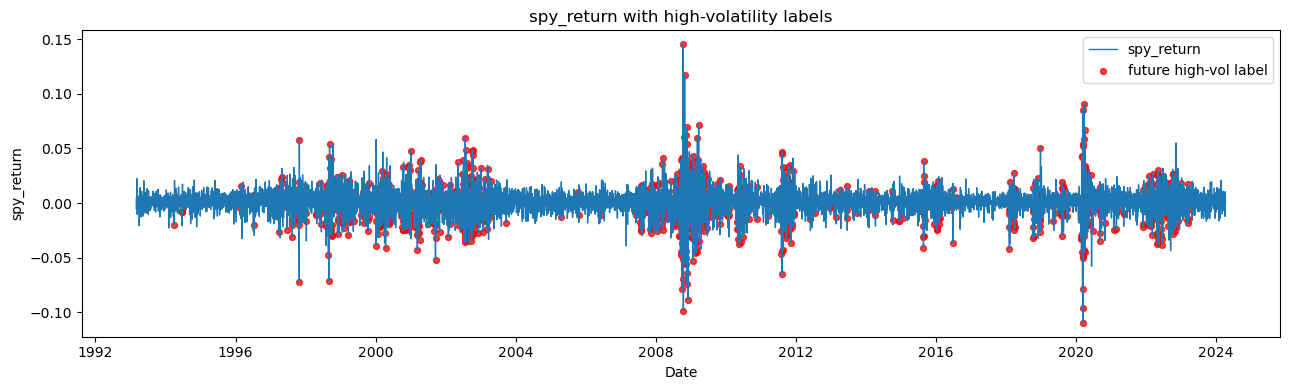

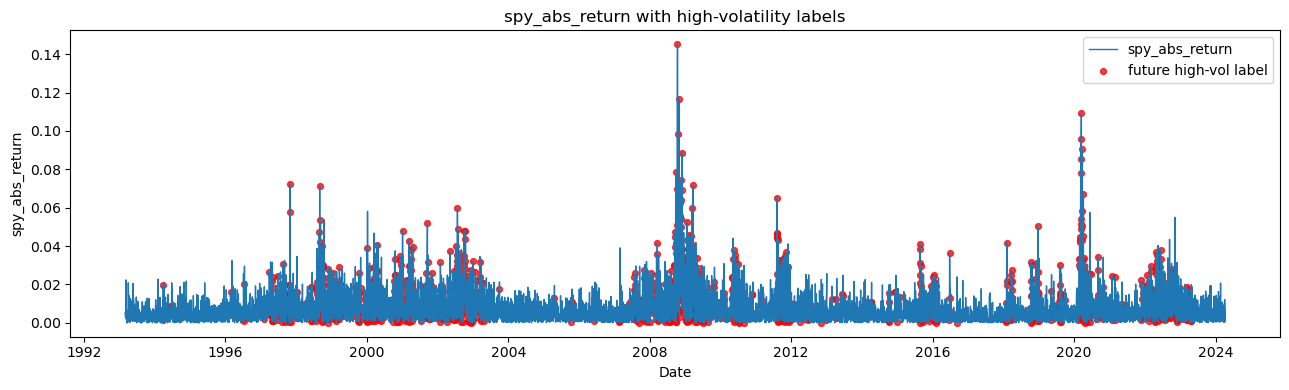

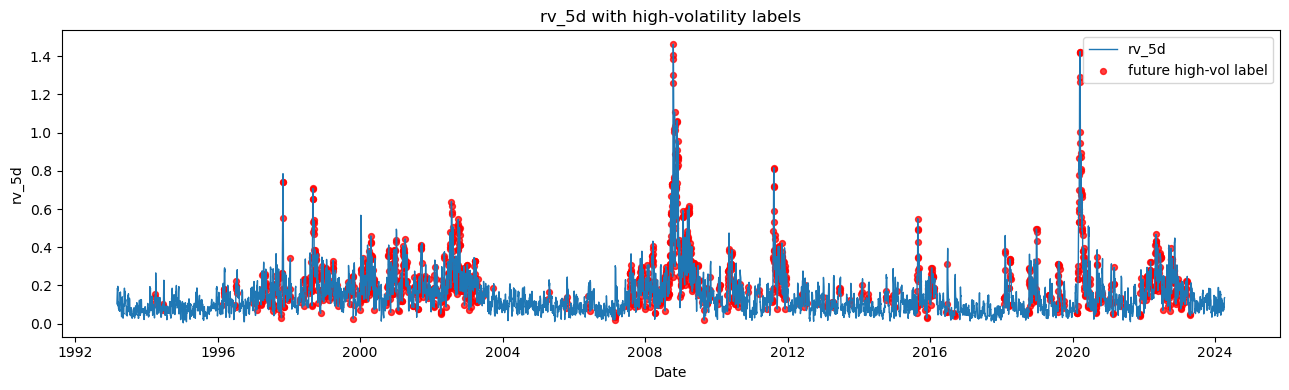

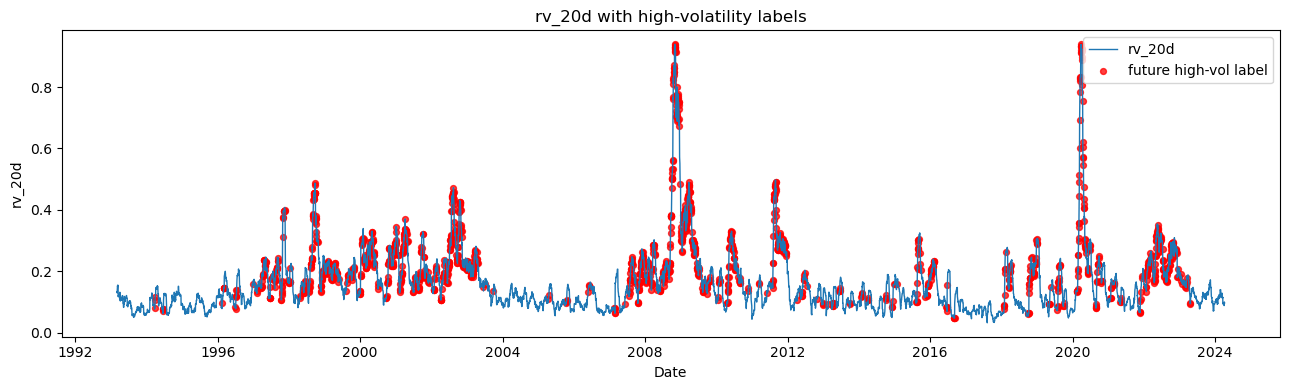

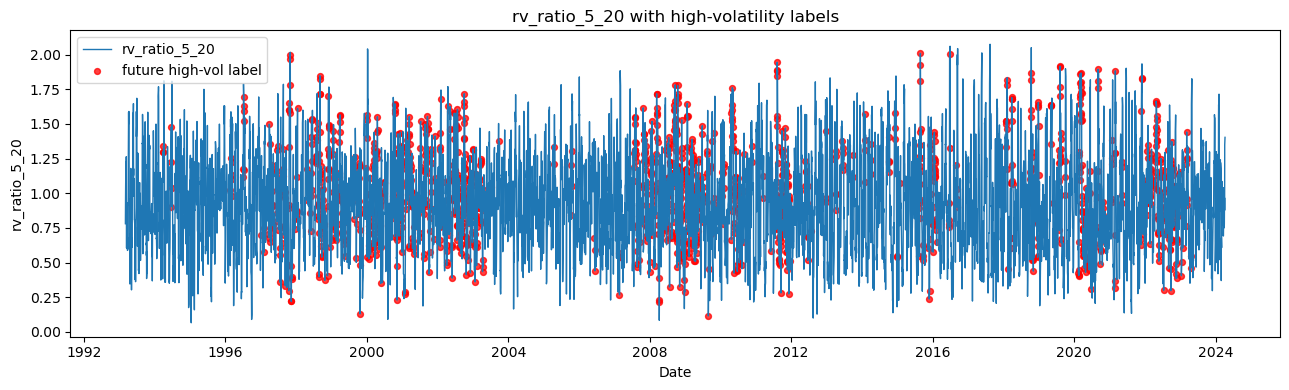

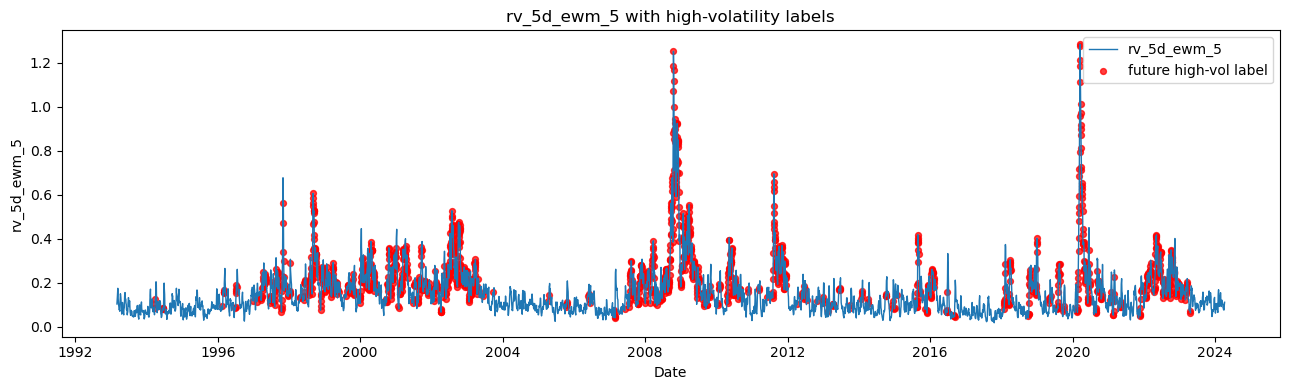

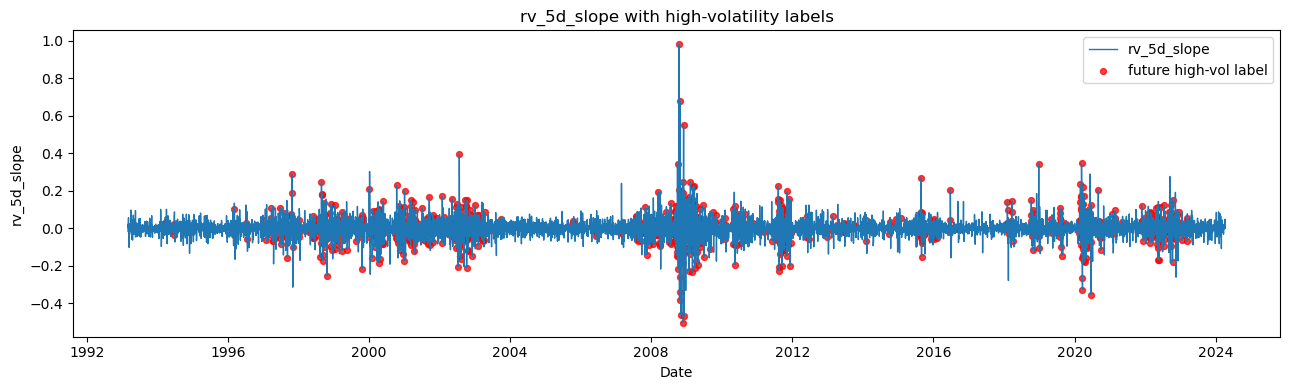

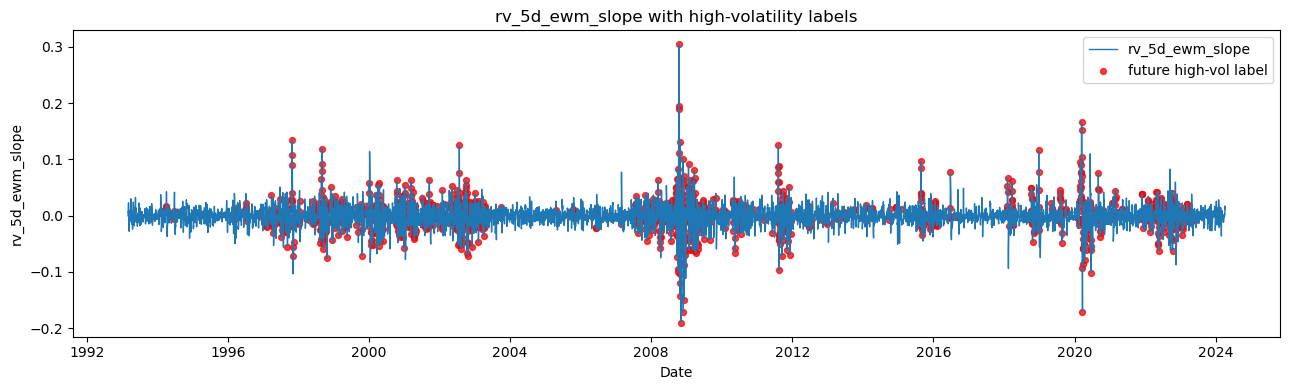

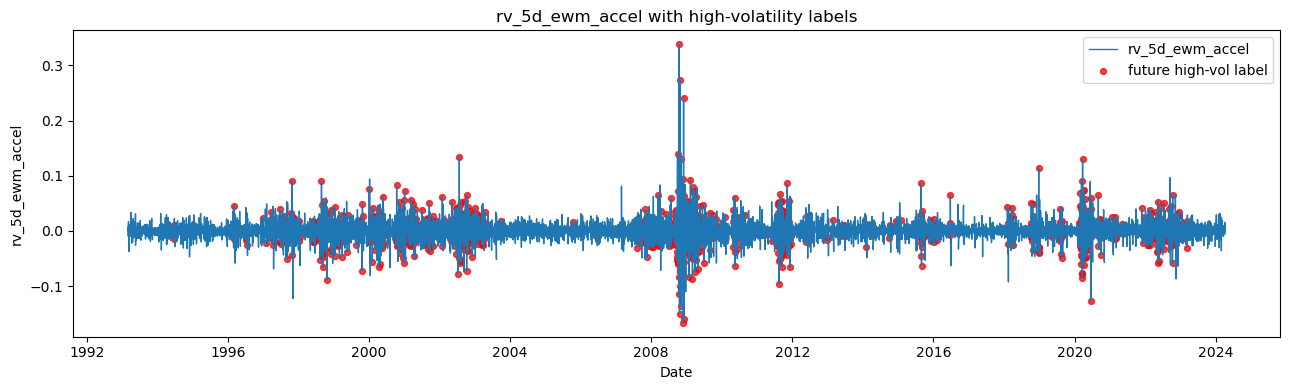

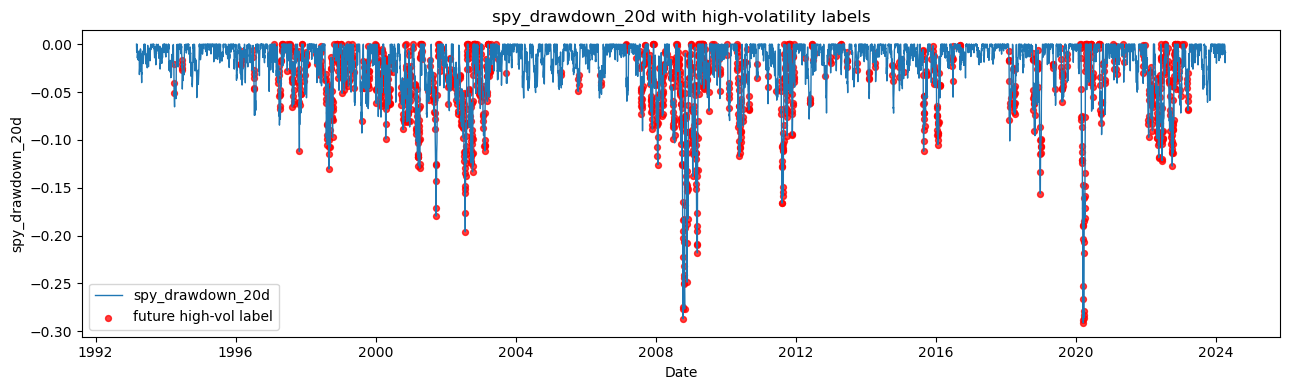

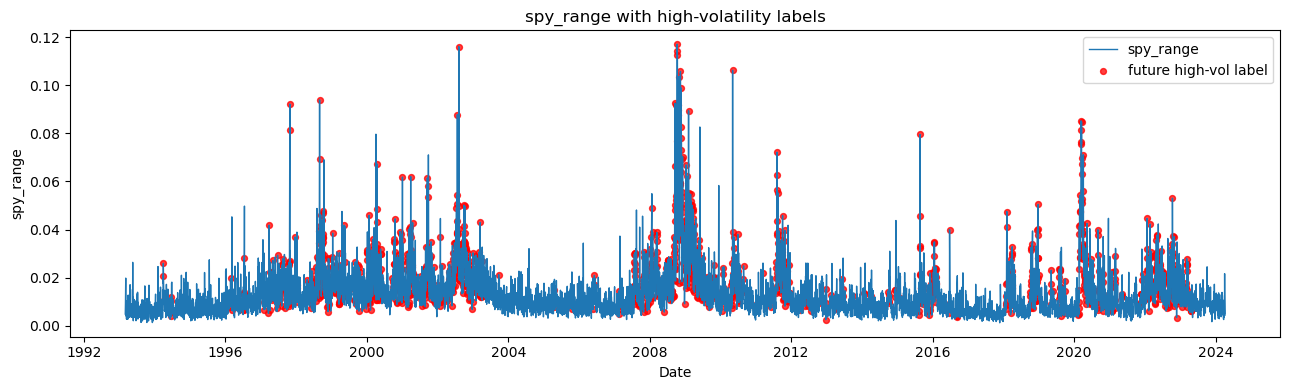

In [5]:
signals = [
    "spy_return",
    "spy_abs_return",
    "rv_5d",
    "rv_20d",
    "rv_ratio_5_20",
    "rv_5d_ewm_5",
    "rv_5d_slope",
    "rv_5d_ewm_slope",
    "rv_5d_ewm_accel",
    "spy_drawdown_20d",
    "spy_range",
]

for col in signals:
    plot_signal_with_labels(df, col, title=f"{col} with high-volatility labels")

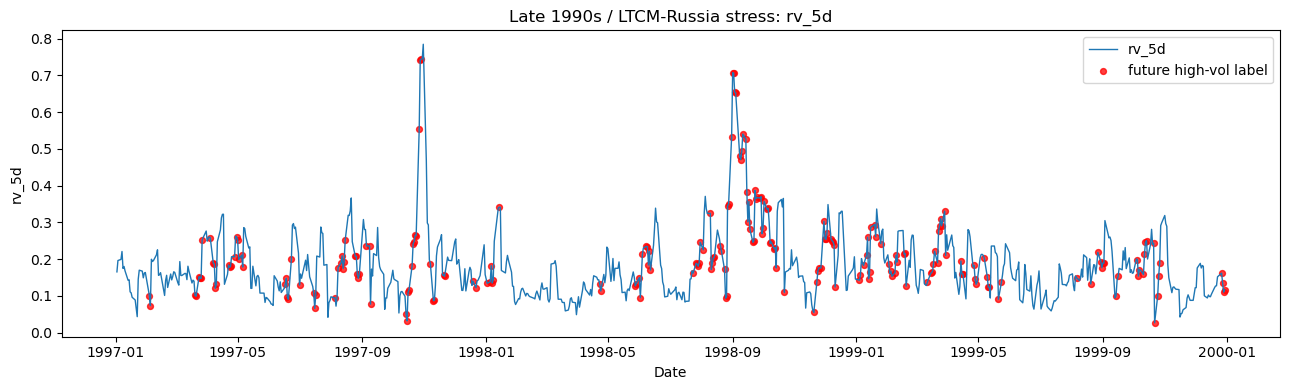

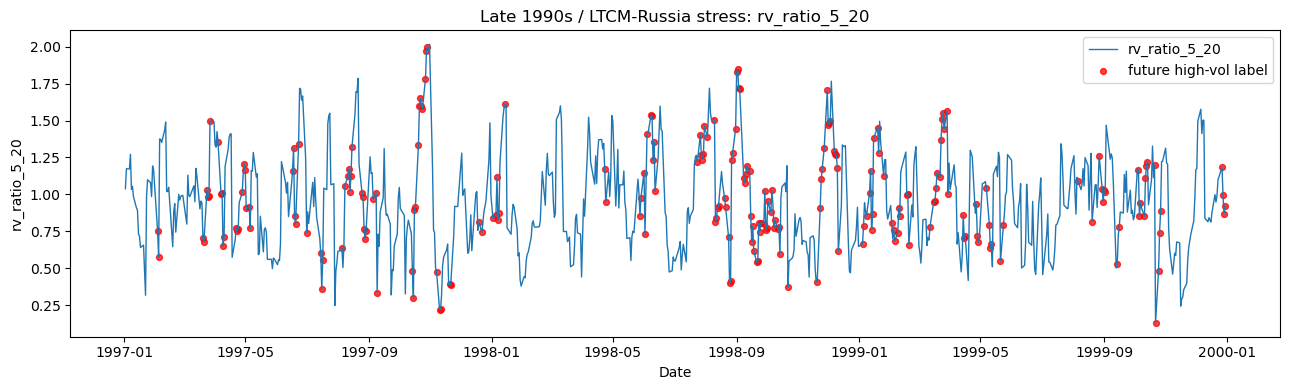

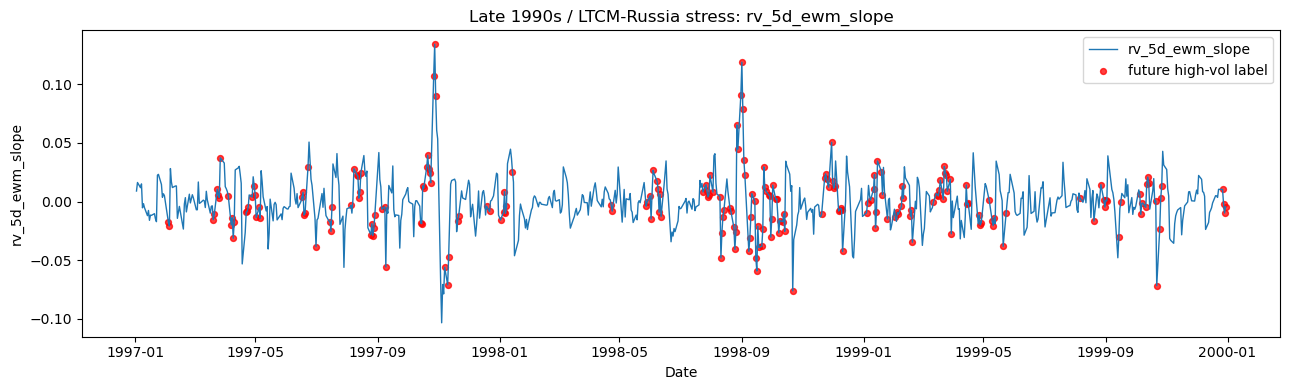

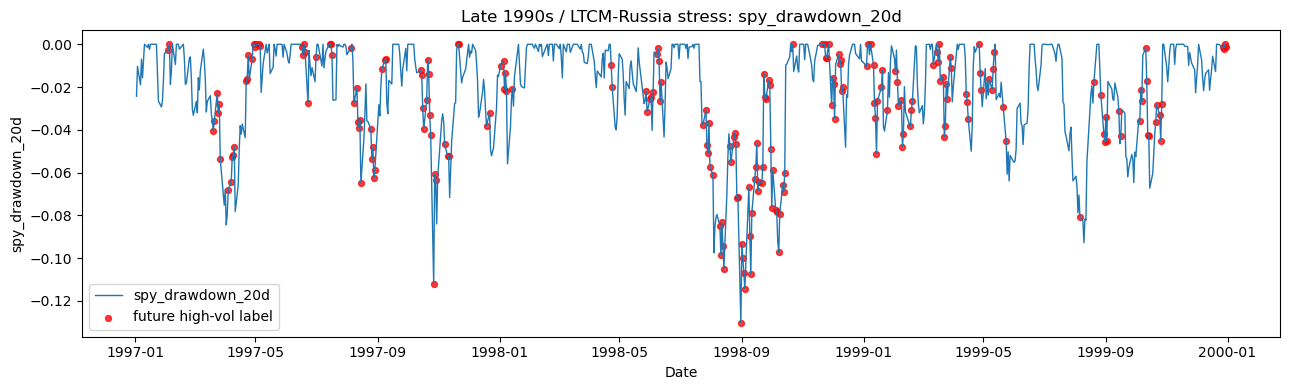

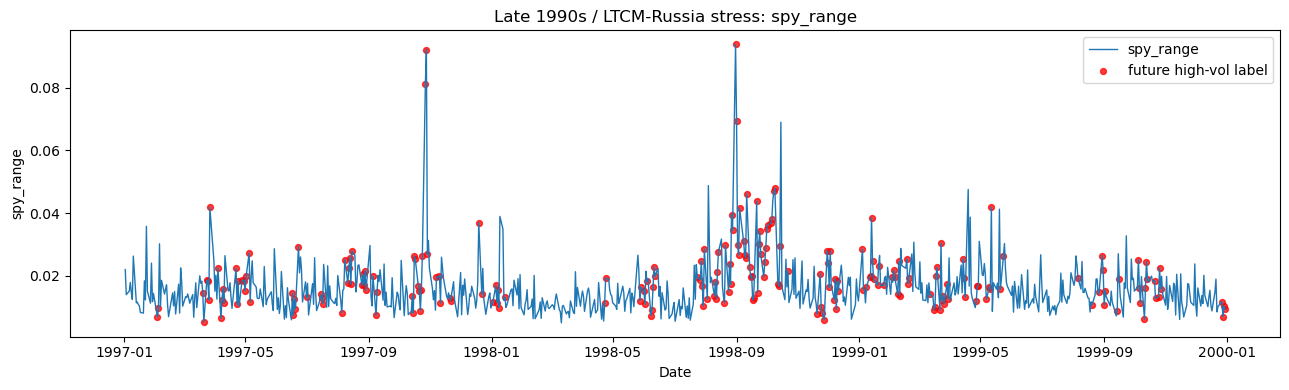

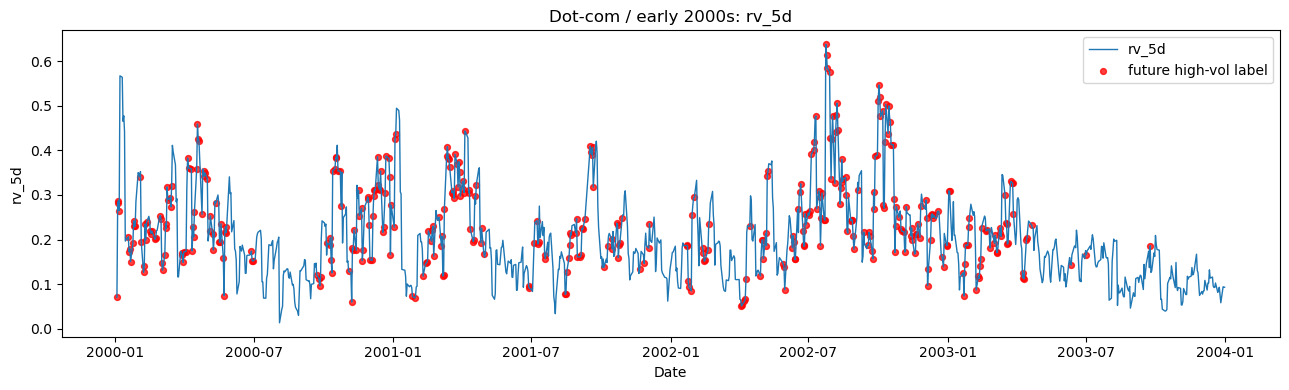

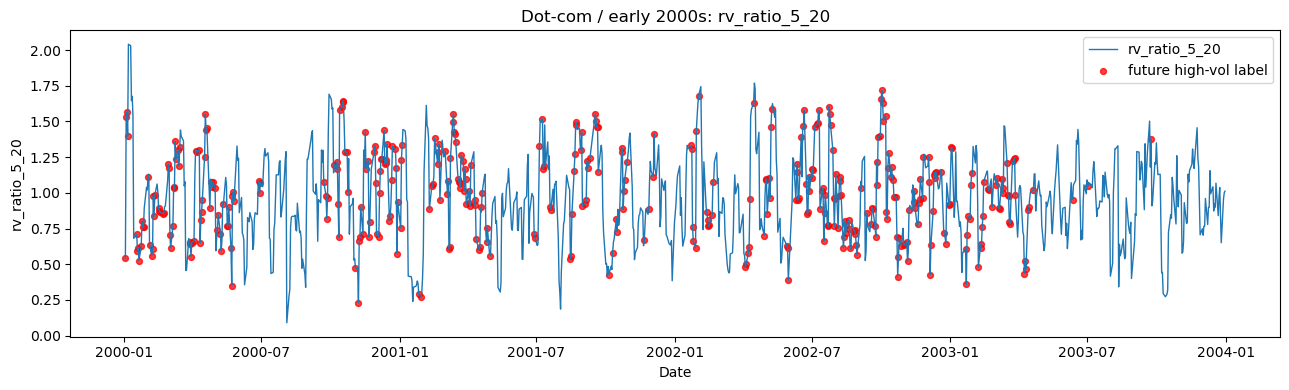

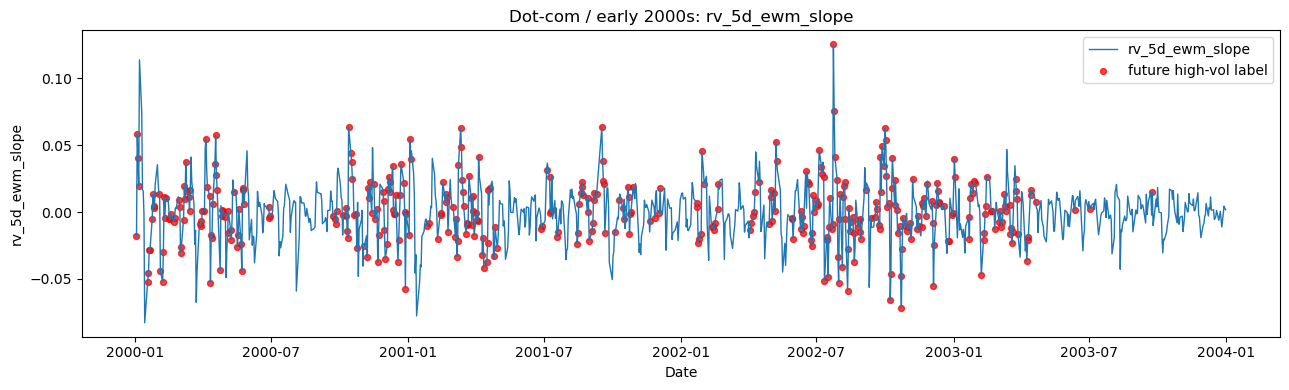

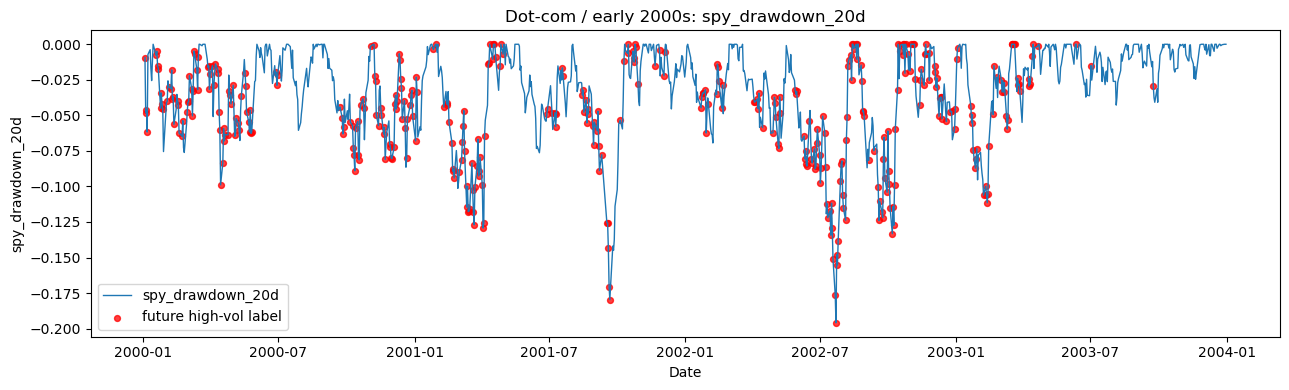

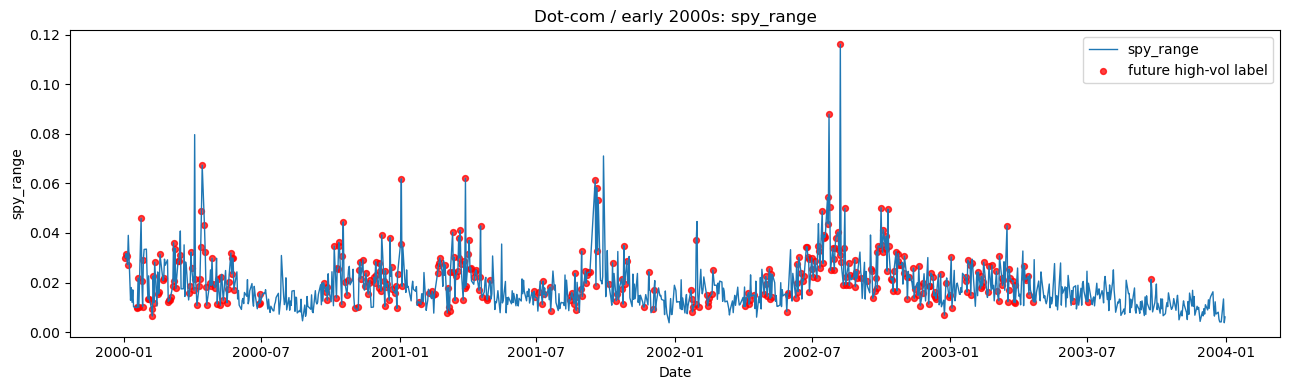

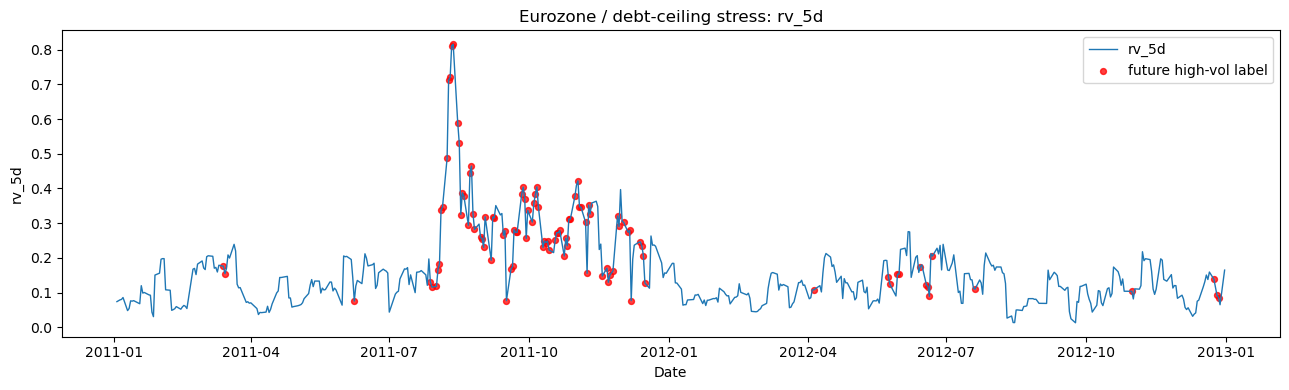

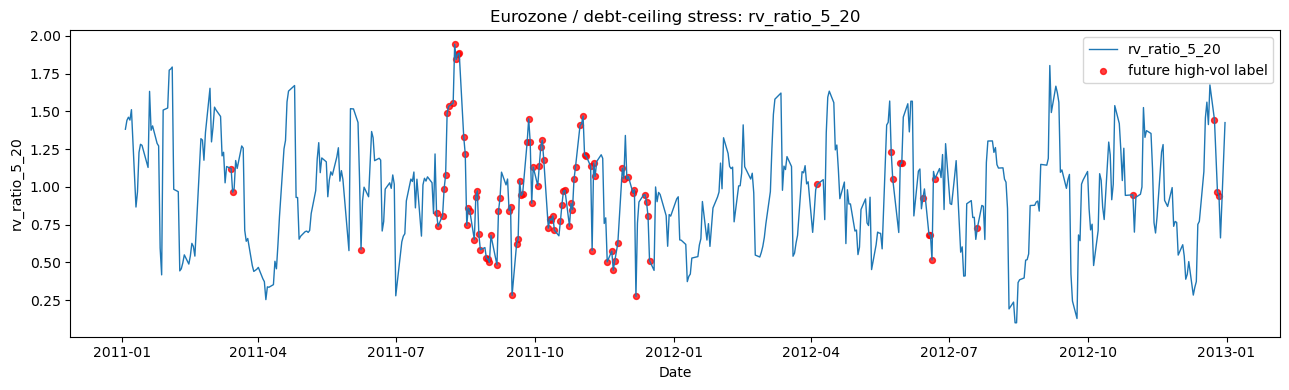

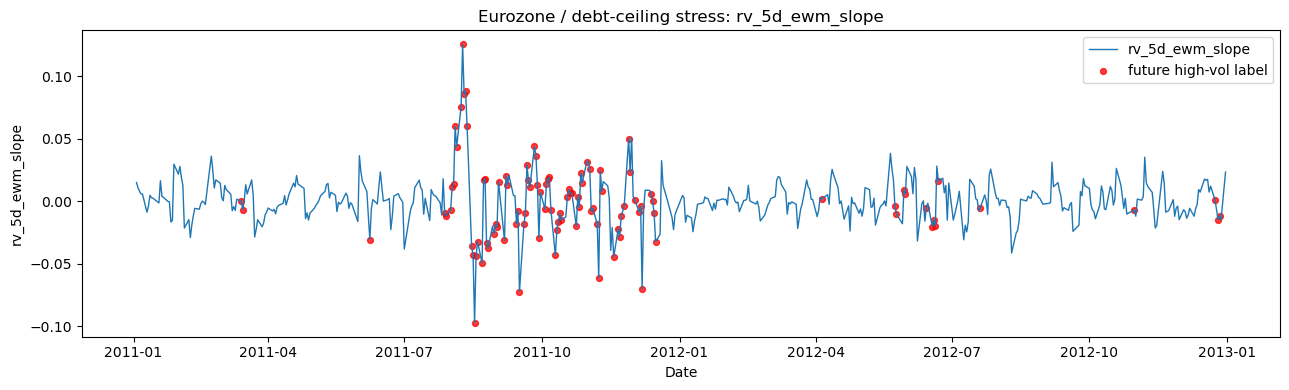

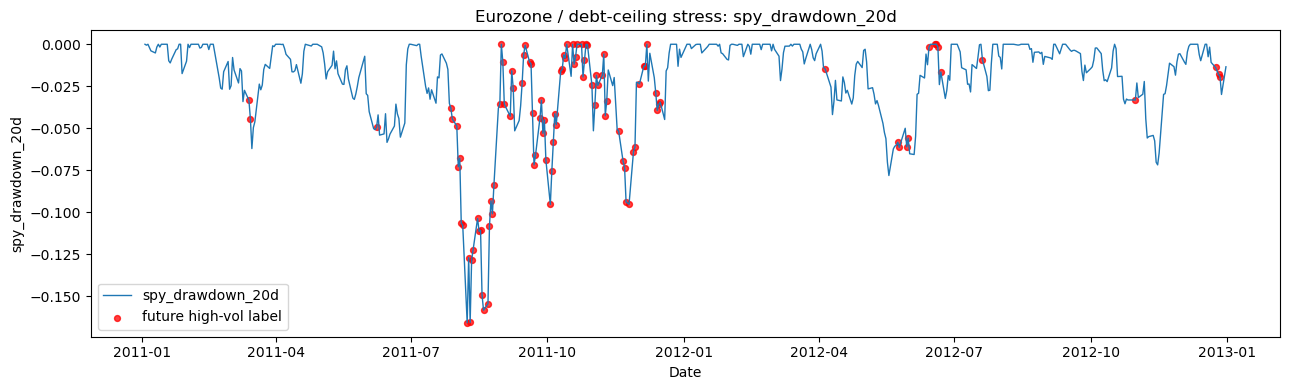

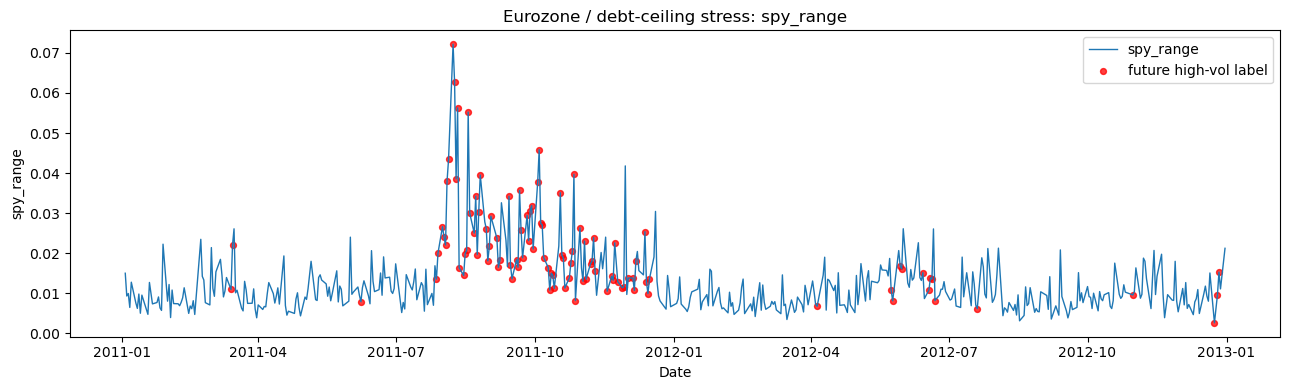

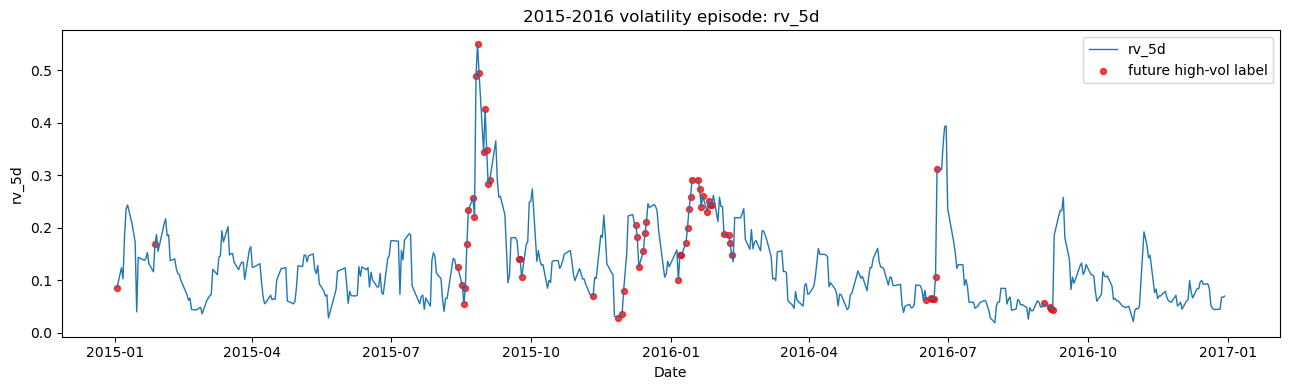

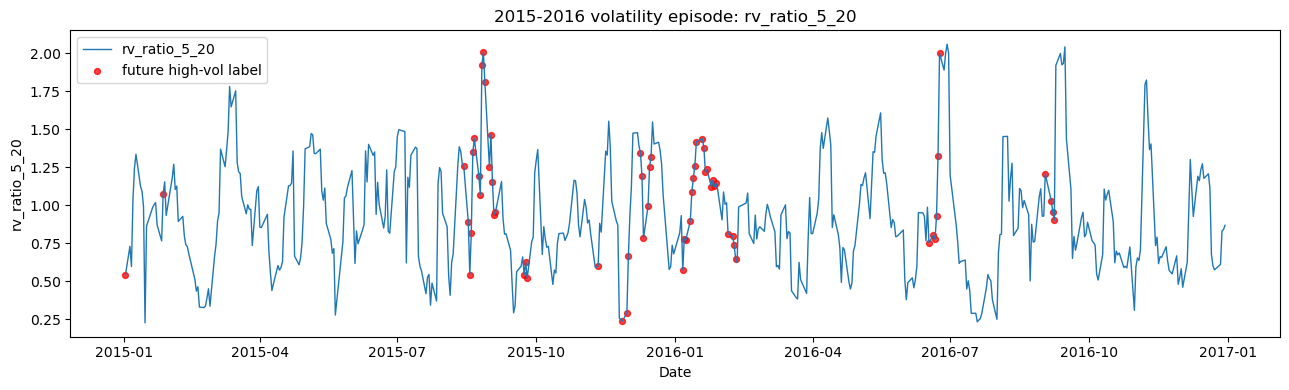

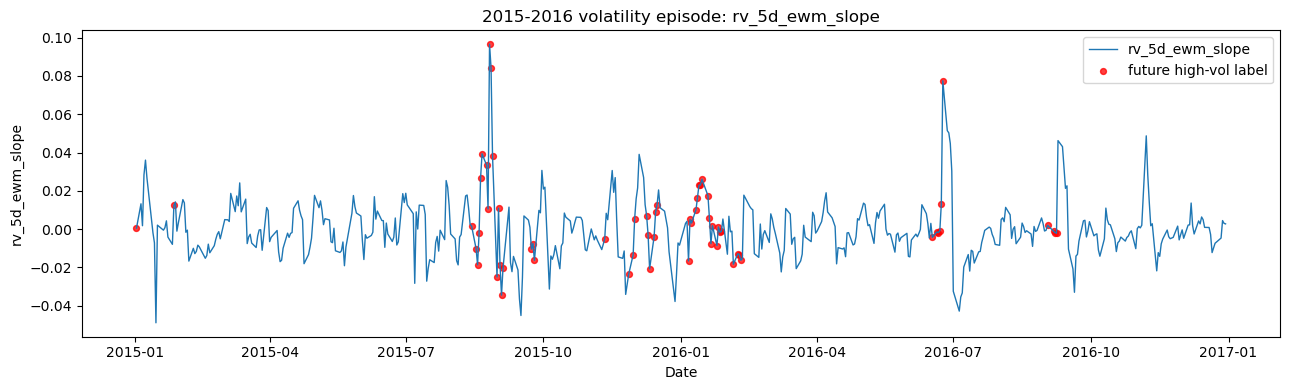

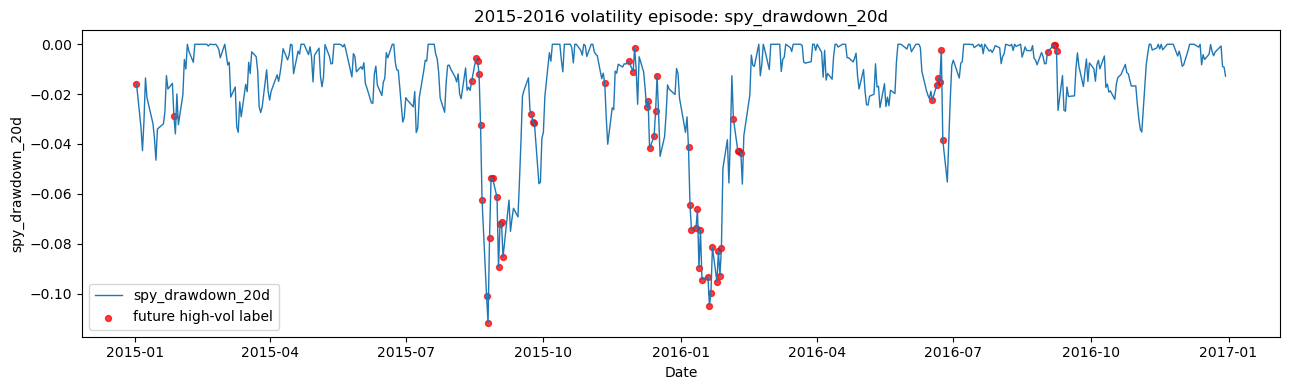

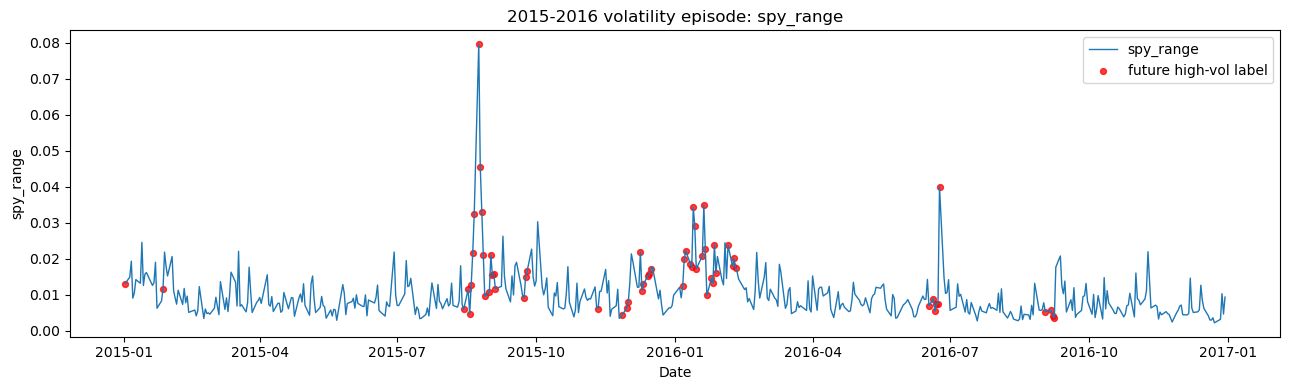

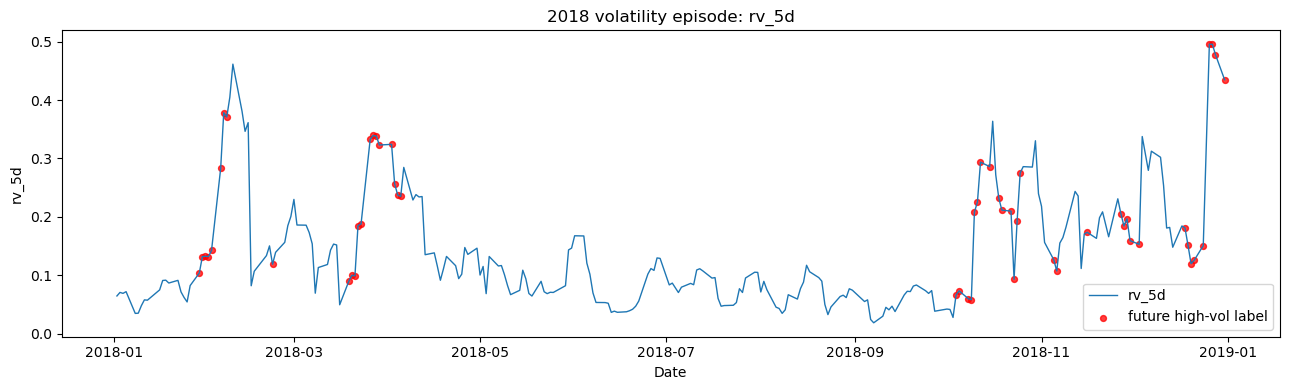

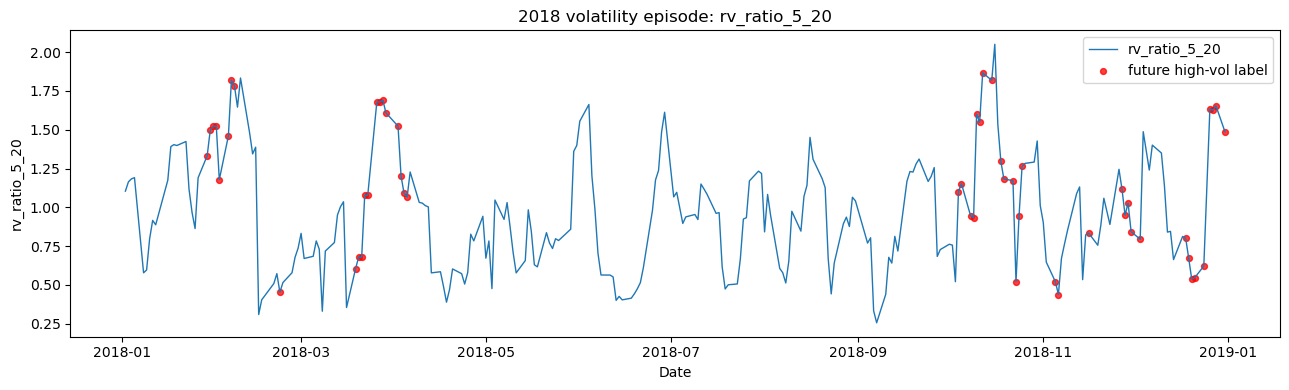

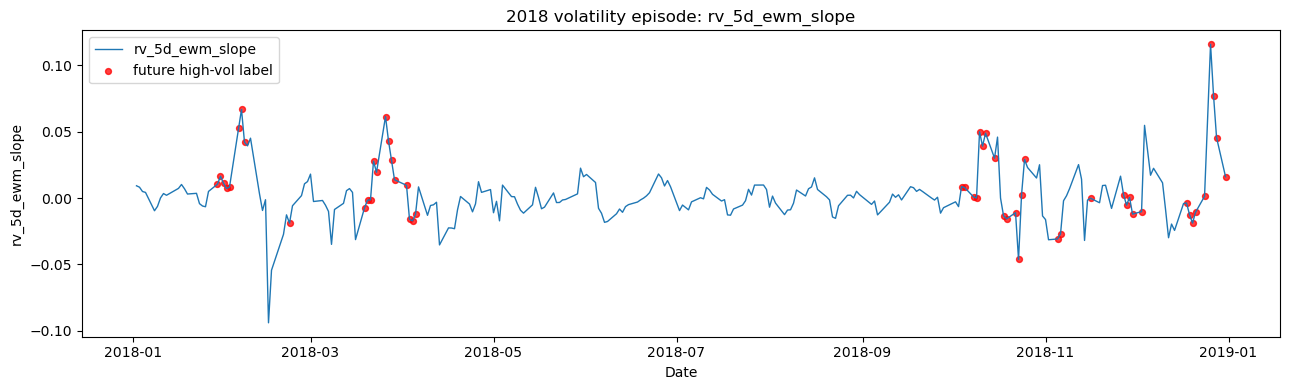

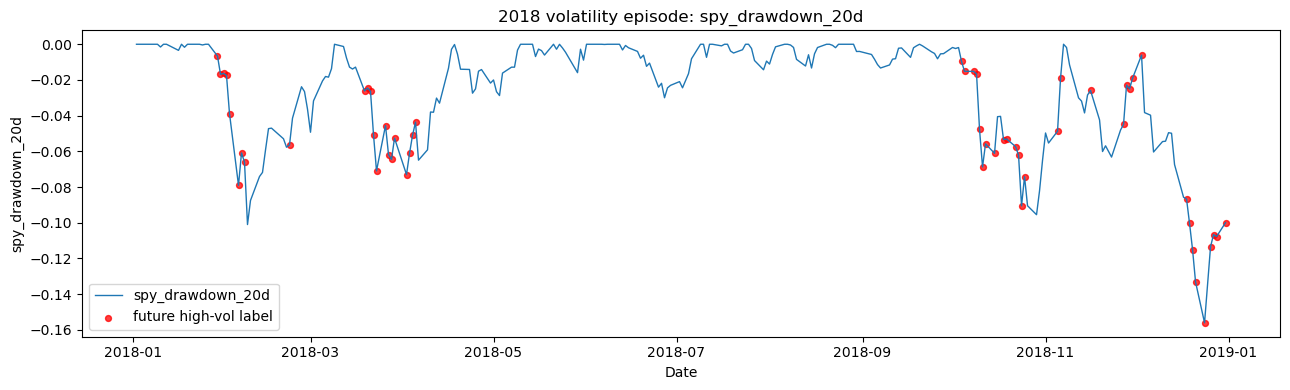

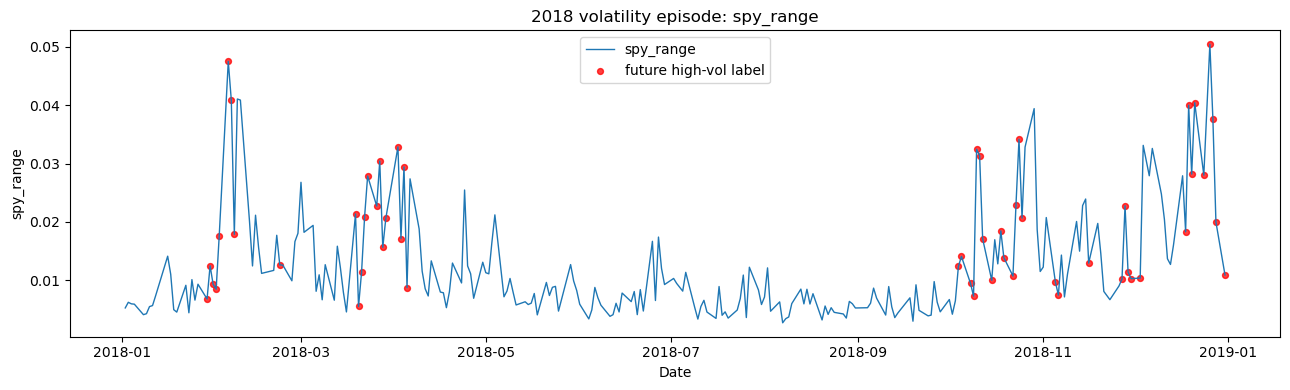

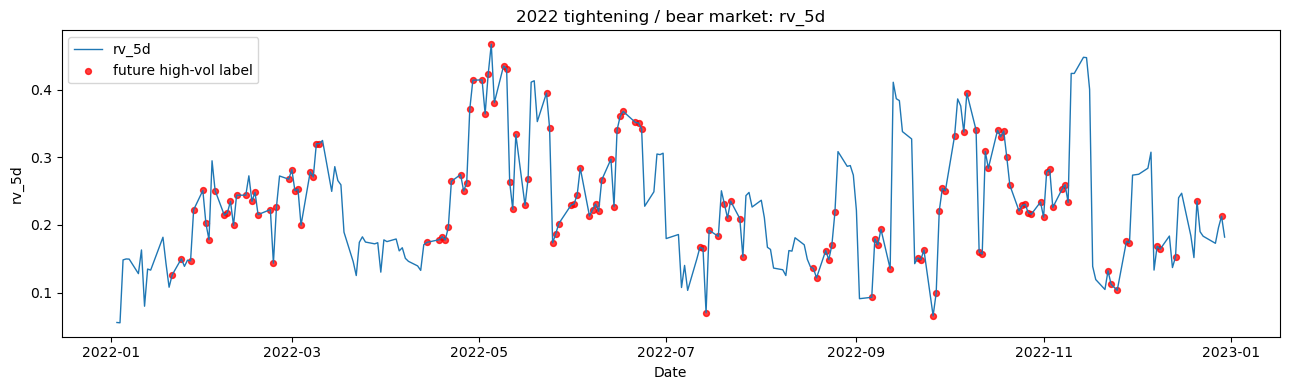

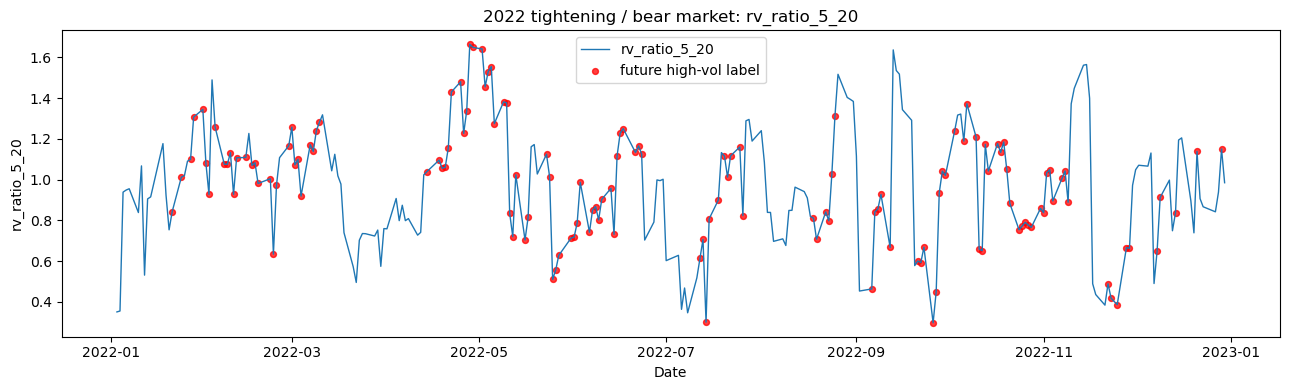

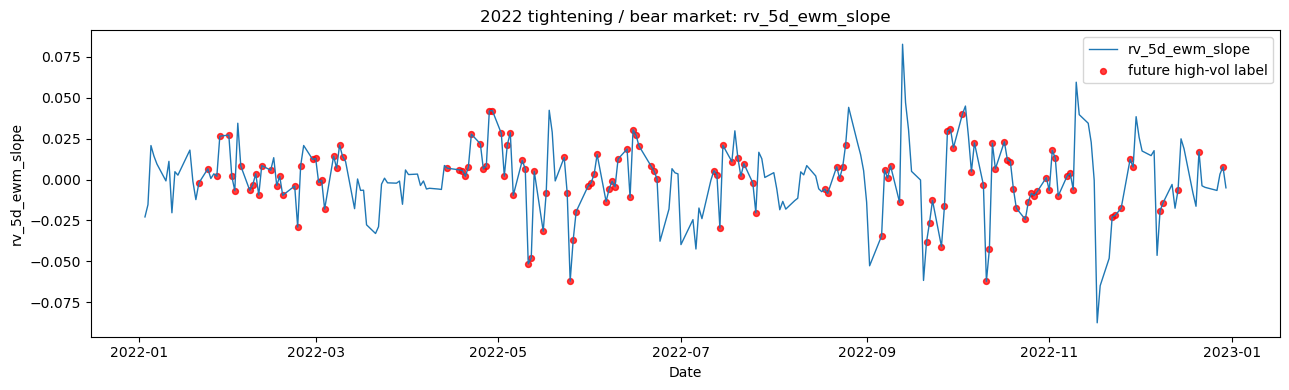

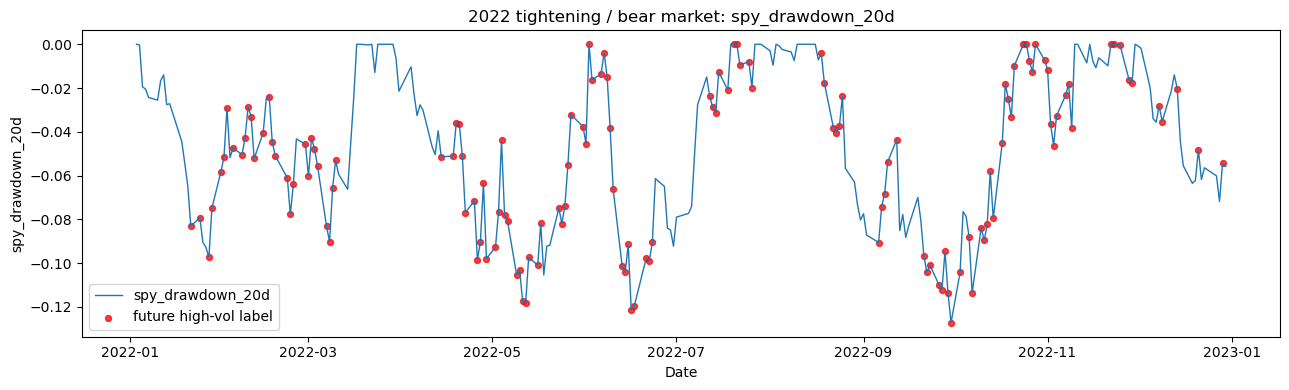

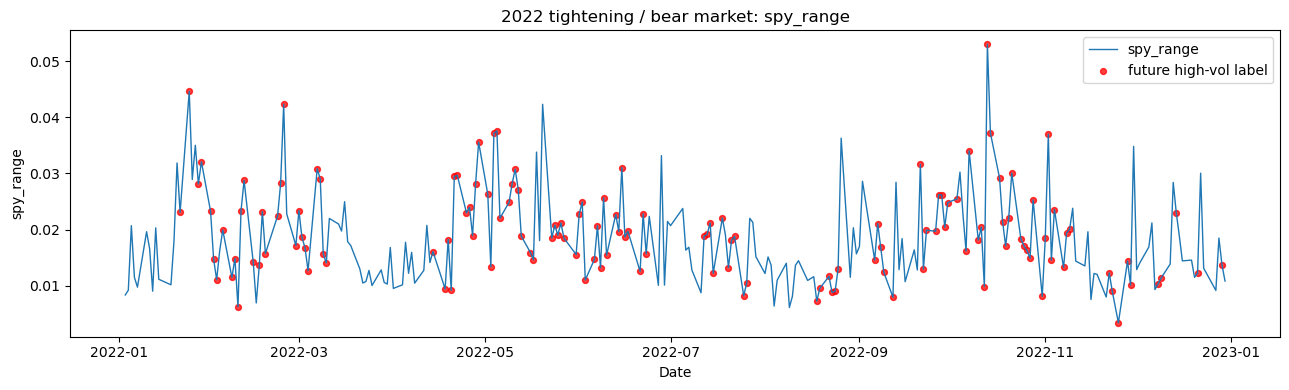

In [6]:
periods = {
    "Late 1990s / LTCM-Russia stress": ("1997-01-01", "1999-12-31"),
    "Dot-com / early 2000s": ("2000-01-01", "2003-12-31"),
    "Eurozone / debt-ceiling stress": ("2011-01-01", "2012-12-31"),
    "2015-2016 volatility episode": ("2015-01-01", "2016-12-31"),
    "2018 volatility episode": ("2018-01-01", "2018-12-31"),
    "2022 tightening / bear market": ("2022-01-01", "2022-12-31"),
}

for name, (start, end) in periods.items():
    for col in ["rv_5d", "rv_ratio_5_20", "rv_5d_ewm_slope", "spy_drawdown_20d", "spy_range"]:
        plot_signal_with_labels(df, col, start=start, end=end, title=f"{name}: {col}")

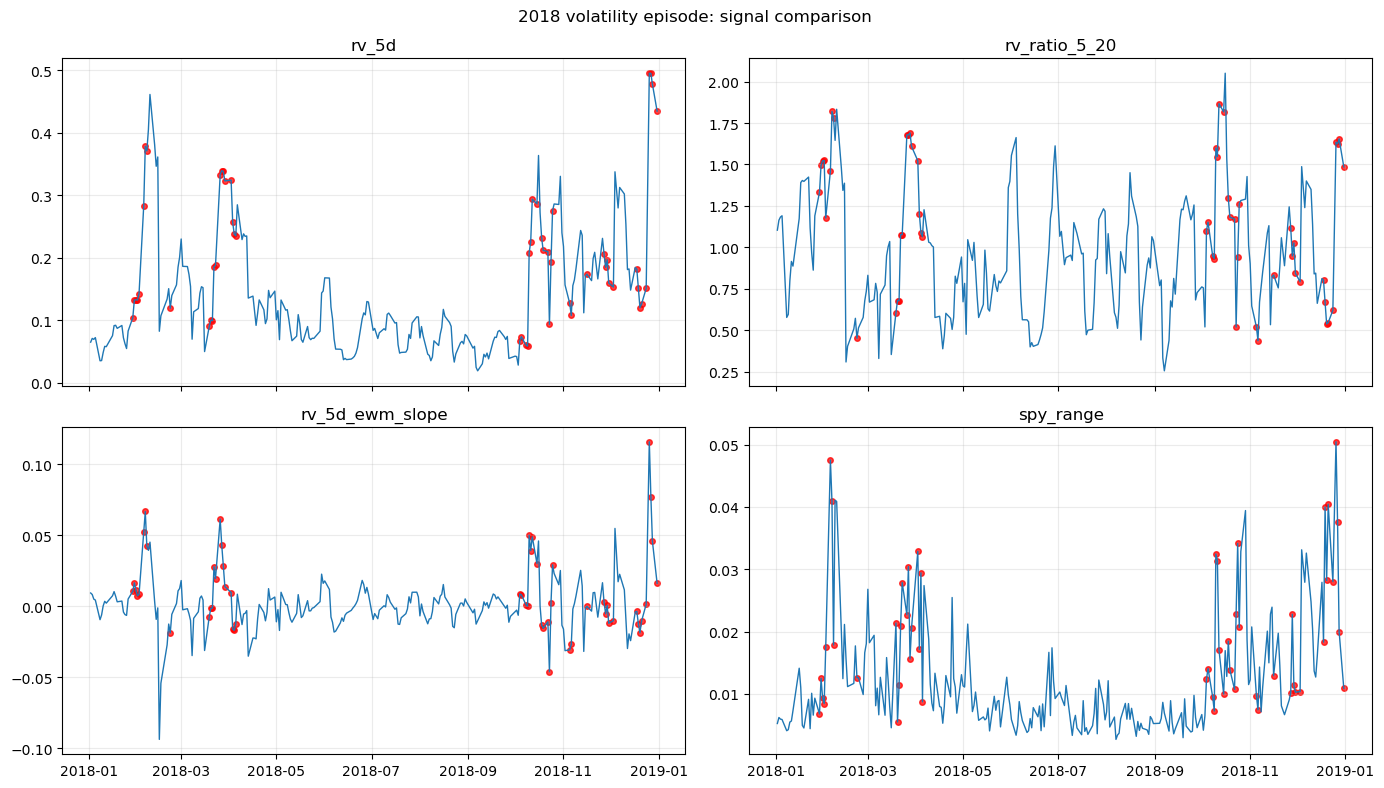

In [7]:
def compare_signals_period(df, start, end, signals, title):
    sub = df[(df["date"] >= start) & (df["date"] <= end)]
    stress = sub[sub["future_high_vol_label"] == 1]

    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
    axes = axes.flatten()

    for ax, col in zip(axes, signals):
        ax.plot(sub["date"], sub[col], linewidth=1, label=col)
        ax.scatter(
            stress["date"],
            stress[col],
            s=16,
            color="red",
            alpha=0.75,
        )
        ax.set_title(col)
        ax.grid(True, alpha=0.25)

    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

compare_signals_period(
    df,
    start="2018-01-01",
    end="2018-12-31",
    signals=["rv_5d", "rv_ratio_5_20", "rv_5d_ewm_slope", "spy_range"],
    title="2018 volatility episode: signal comparison",
)

In [19]:
# amplitude-like signal
df["abs_return_ewm_5"] = df["spy_abs_return"].ewm(span=5, adjust=False).mean()
df["abs_return_ewm_10"] = df["spy_abs_return"].ewm(span=10, adjust=False).mean()

# slope / derivative of smoothed amplitude
df["abs_return_ewm_5_slope"] = df["abs_return_ewm_5"].diff()
df["abs_return_ewm_10_slope"] = df["abs_return_ewm_10"].diff()

# smoothed realized volatility
df["rv_5d_ewm_5"] = df["rv_5d"].ewm(span=5, adjust=False).mean()
df["rv_5d_ewm_10"] = df["rv_5d"].ewm(span=10, adjust=False).mean()

# slope of smoothed volatility
df["rv_5d_ewm_5_slope"] = df["rv_5d_ewm_5"].diff()
df["rv_5d_ewm_10_slope"] = df["rv_5d_ewm_10"].diff()

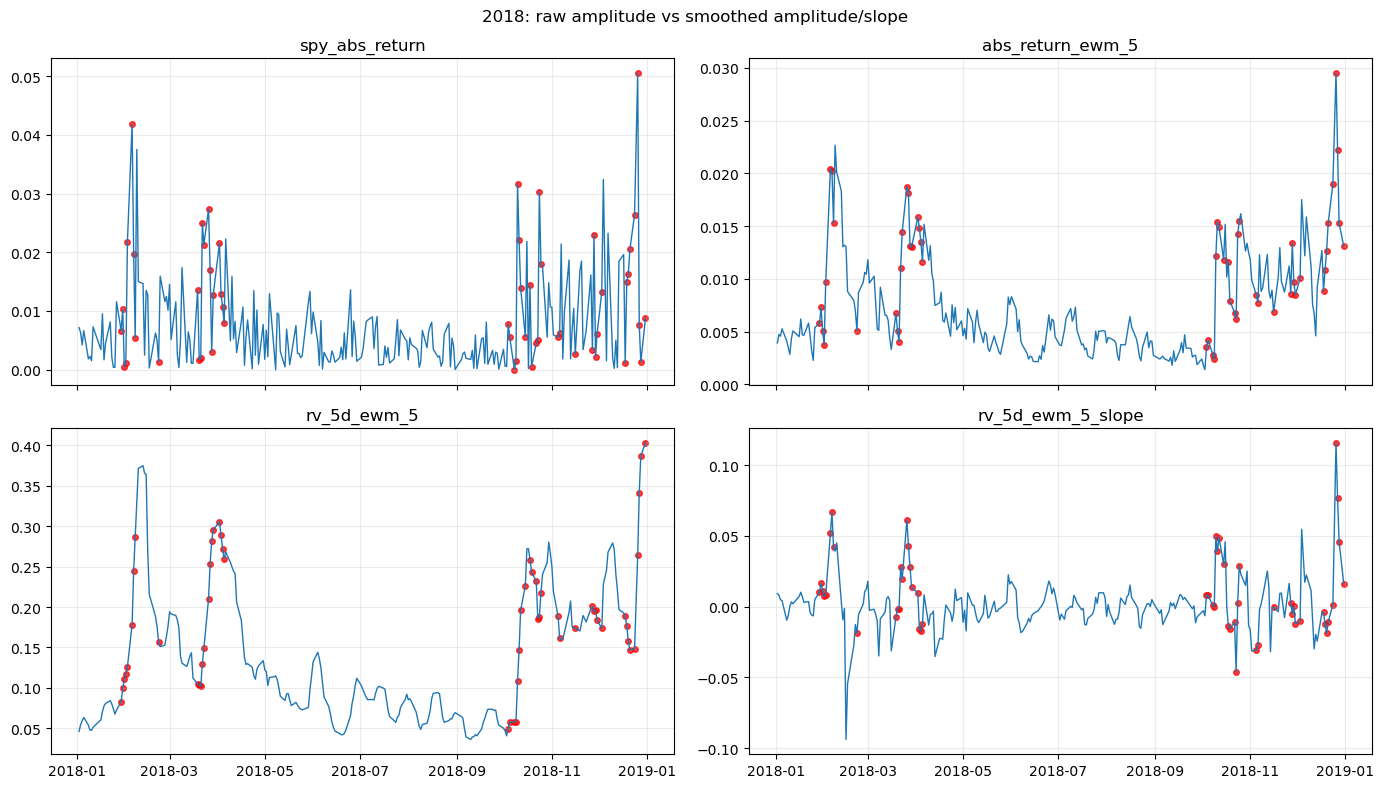

In [9]:
compare_signals_period(
    df.dropna(),
    start="2018-01-01",
    end="2018-12-31",
    signals=[
        "spy_abs_return",
        "abs_return_ewm_5",
        "rv_5d_ewm_5",
        "rv_5d_ewm_5_slope",
    ],
    title="2018: raw amplitude vs smoothed amplitude/slope",
)

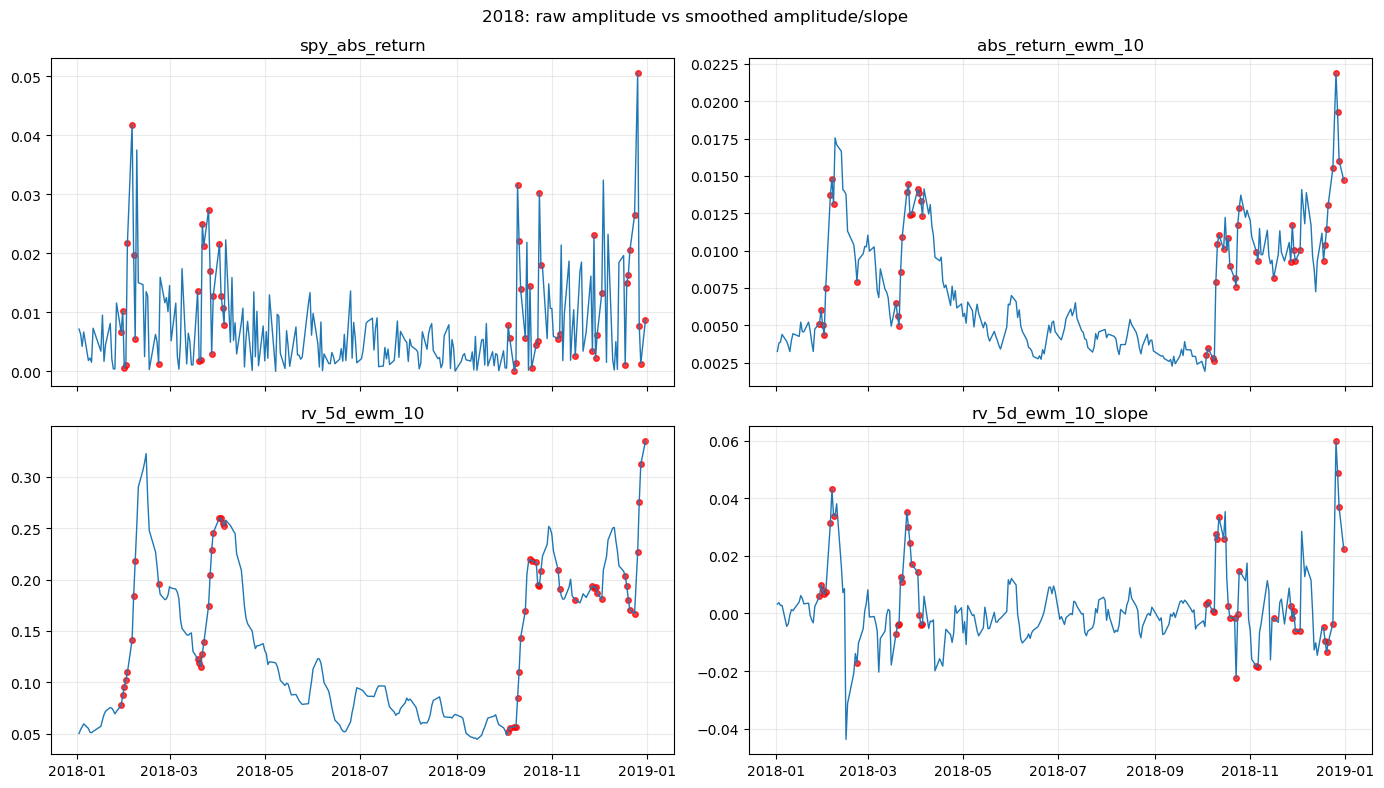

In [20]:
compare_signals_period(
    df.dropna(),
    start="2018-01-01",
    end="2018-12-31",
    signals=[
        "spy_abs_return",
        "abs_return_ewm_10",
        "rv_5d_ewm_10",
        "rv_5d_ewm_10_slope",
    ],
    title="2018: raw amplitude vs smoothed amplitude/slope",
)

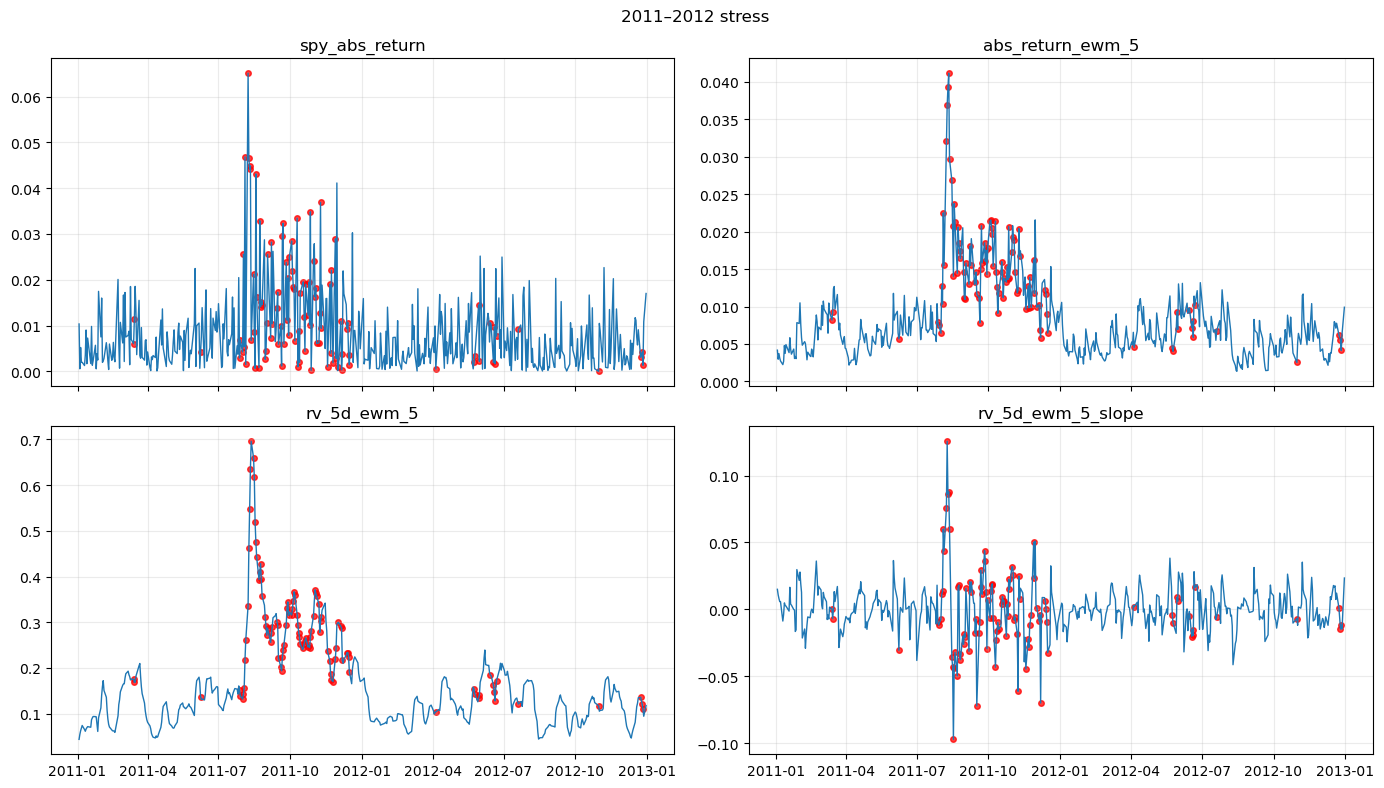

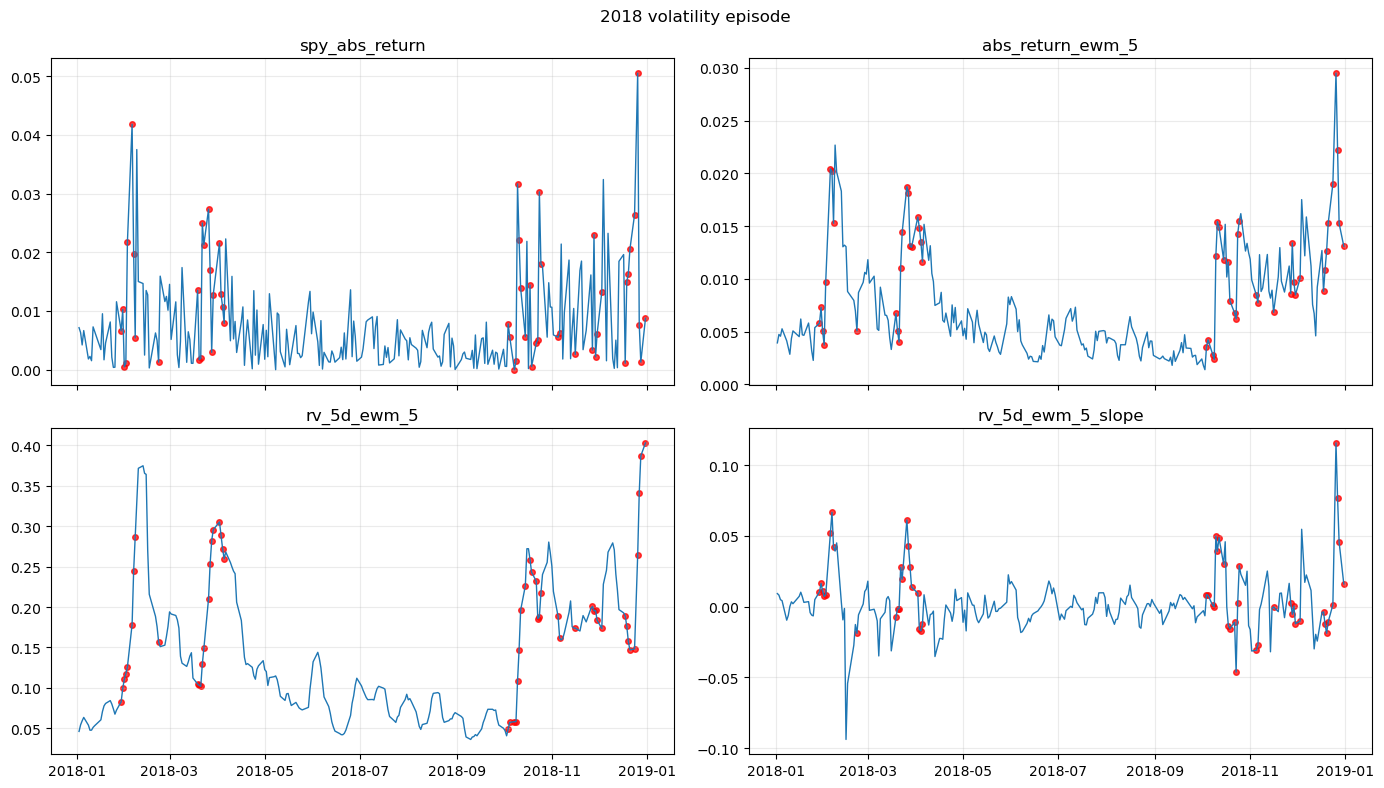

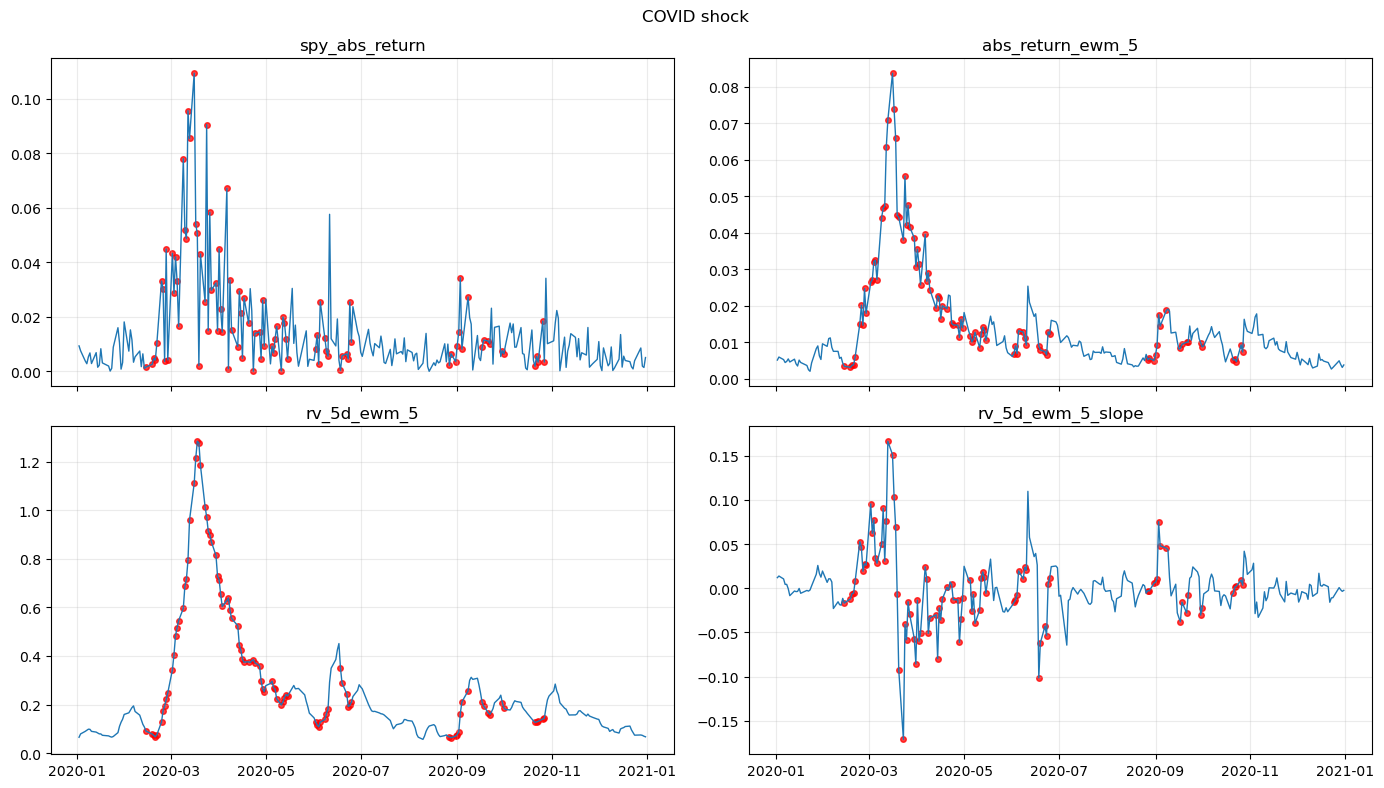

In [21]:
for start, end, title in [
    ("2011-01-01", "2012-12-31", "2011–2012 stress"),
    ("2018-01-01", "2018-12-31", "2018 volatility episode"),
    ("2020-01-01", "2020-12-31", "COVID shock"),
]:
    compare_signals_period(
        df.dropna(),
        start=start,
        end=end,
        signals=[
            "spy_abs_return",
            "abs_return_ewm_5",
            "rv_5d_ewm_5",
            "rv_5d_ewm_5_slope",
        ],
        title=title,
    )

In [22]:
for span in [5, 10, 20, 40]:
    df[f"abs_return_ewm_{span}"] = df["spy_abs_return"].ewm(span=span, adjust=False).mean()
    df[f"rv_5d_ewm_{span}"] = df["rv_5d"].ewm(span=span, adjust=False).mean()

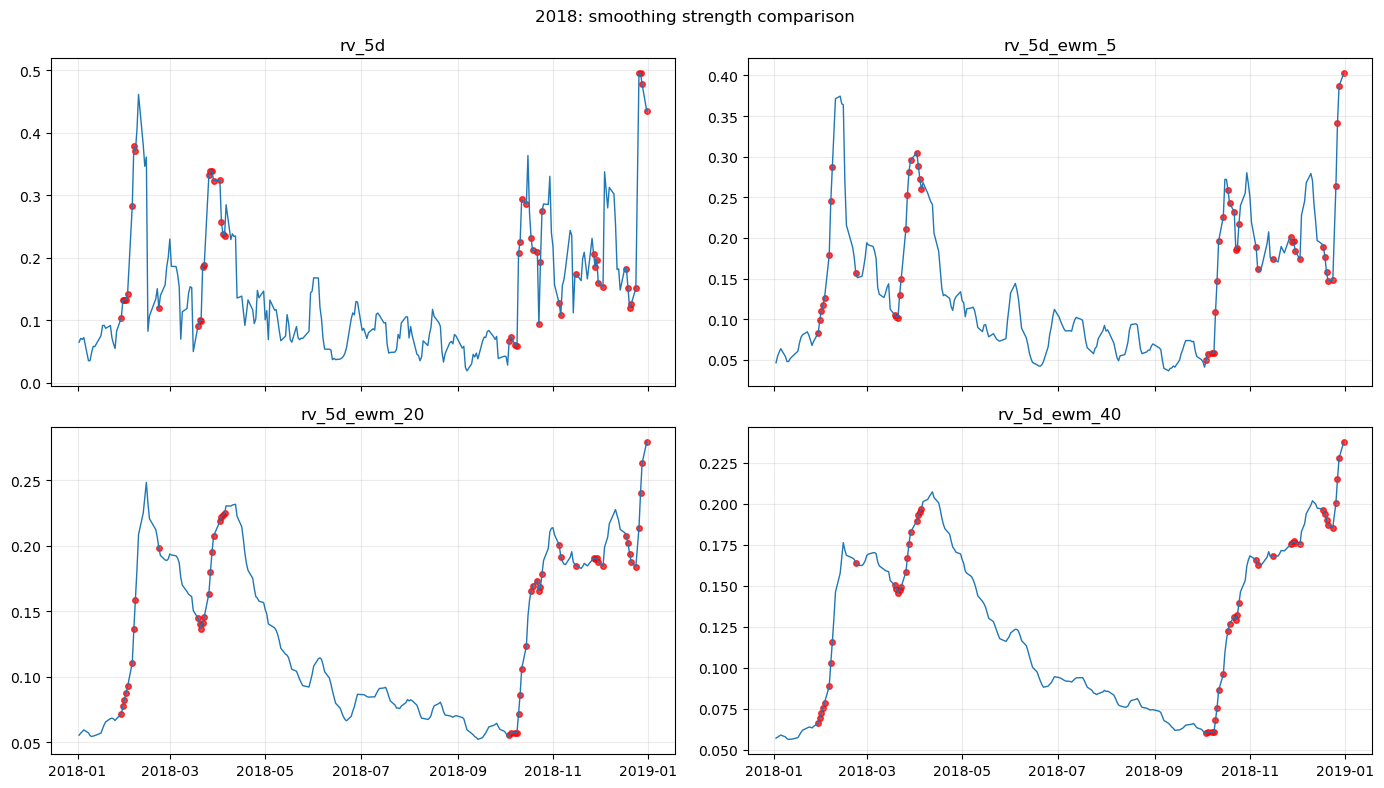

In [23]:
compare_signals_period(
    df.dropna(),
    start="2018-01-01",
    end="2018-12-31",
    signals=[
        "rv_5d",
        "rv_5d_ewm_5",
        "rv_5d_ewm_20",
        "rv_5d_ewm_40",
    ],
    title="2018: smoothing strength comparison",
)